# Init

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import torch
from typing import Any, Callable, Dict, List, Optional, Union
from diffusers import StableDiffusionPipeline
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline, DDIMScheduler
from tqdm import tqdm
from PIL import Image
from typing import Optional
import torch.nn.functional as F

import umap


device = "cuda:0" if torch.cuda.is_available() else "cpu"



In [3]:
def resize_by_scale(image,scale=0.25):
    resized_image = image.resize( [int(scale * s) for s in image.size],  Image.Resampling.LANCZOS)
    return resized_image

In [4]:
# mask support
class CustomStableDiffusionPipeline(StableDiffusionPipeline):
    """Stable Diffusion pipeline with encoder attention mask passthrough.

    This subclass avoids duplicating the full generation loop by temporarily
    wrapping `self.unet.forward` during `__call__` and injecting
    `encoder_attention_mask` into each UNet invocation.

    In classifier-free guidance mode, the base pipeline concatenates
    `[negative_prompt_embeds, prompt_embeds]`. If the provided mask matches only
    the positive branch, this subclass expands it to a full batch by prepending
    an all-ones mask for the negative branch.
    """

    @torch.no_grad()
    def __call__(self, *args, encoder_attention_mask: Optional[torch.Tensor] = None, **kwargs):
        if encoder_attention_mask is None:
            return super().__call__(*args, **kwargs)

        original_unet_forward = self.unet.forward

        def patched_unet_forward(*unet_args, **unet_kwargs):
            if unet_kwargs.get("encoder_attention_mask", None) is None:
                final_encoder_attention_mask = encoder_attention_mask
                encoder_hidden_states = unet_kwargs.get("encoder_hidden_states", None)

                if not torch.is_tensor(final_encoder_attention_mask):
                    final_encoder_attention_mask = torch.tensor(final_encoder_attention_mask)

                if encoder_hidden_states is not None:
                    final_encoder_attention_mask = final_encoder_attention_mask.to(
                        device=encoder_hidden_states.device, dtype=torch.bool
                    )
                else:
                    final_encoder_attention_mask = final_encoder_attention_mask.to(dtype=torch.bool)

                if encoder_hidden_states is None and len(unet_args) >= 3:
                    encoder_hidden_states = unet_args[2]

                    final_encoder_attention_mask = final_encoder_attention_mask.to(
                        device=encoder_hidden_states.device, dtype=torch.bool
                    )

                if encoder_hidden_states is not None and self.do_classifier_free_guidance:
                    target_batch = encoder_hidden_states.shape[0]
                    if target_batch % 2 == 0:
                        cond_batch = target_batch // 2

                        if final_encoder_attention_mask.ndim == 1:
                            final_encoder_attention_mask = final_encoder_attention_mask.unsqueeze(0)

                        if final_encoder_attention_mask.shape[0] == 1:
                            positive_encoder_attention_mask = final_encoder_attention_mask.repeat(cond_batch, 1)
                            negative_encoder_attention_mask = torch.ones_like(positive_encoder_attention_mask)
                            final_encoder_attention_mask = torch.cat(
                                [negative_encoder_attention_mask, positive_encoder_attention_mask], dim=0
                            )
                        elif final_encoder_attention_mask.shape[0] == cond_batch:
                            negative_encoder_attention_mask = torch.ones_like(final_encoder_attention_mask)
                            final_encoder_attention_mask = torch.cat(
                                [negative_encoder_attention_mask, final_encoder_attention_mask], dim=0
                            )

                unet_kwargs["encoder_attention_mask"] = final_encoder_attention_mask
                
                
                # print(f"encoder_hidden_states.shape: {encoder_hidden_states.shape if encoder_hidden_states is not None else None}")
                # print(f"encoder_attention_mask.shape: {final_encoder_attention_mask.shape}")
                
                # print(f"encoder_attention_mask (first 10 elements of first row): {final_encoder_attention_mask[0][:10]}")
                # print(f"encoder_attention_mask (first 10 elements of second row): {final_encoder_attention_mask[1][:10]}")

            return original_unet_forward(*unet_args, **unet_kwargs)

        self.unet.forward = patched_unet_forward
        try:
            return super().__call__(*args, **kwargs)
        finally:
            self.unet.forward = original_unet_forward


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    import umap
except ImportError:
    umap = None


def kmean_clustering(
    embeddings,
    k=10,
    is_normalize=False,
    show_plot=True,
    projection_plot="pca",
    labels=None,
    random_state=42,
    plot_title=None,
):
    if hasattr(embeddings, "detach"):
        embedding_array = embeddings.detach().float().cpu().numpy()
    else:
        embedding_array = np.asarray(embeddings, dtype=np.float32)

    if embedding_array.ndim != 2:
        raise ValueError(
            f"Expected a 2D array of shape [n_samples, n_features], got {embedding_array.shape}."
        )

    if k < 1 or k > embedding_array.shape[0]:
        raise ValueError(
            f"k must be between 1 and the number of embeddings ({embedding_array.shape[0]}), got {k}."
        )

    if labels is not None and len(labels) != embedding_array.shape[0]:
        raise ValueError(
            "labels must have the same length as the number of embeddings. "
            f"Got {len(labels)} labels for {embedding_array.shape[0]} embeddings."
        )

    clustering_input = embedding_array.copy()
    if is_normalize:
        norms = np.linalg.norm(clustering_input, axis=1, keepdims=True)
        norms = np.clip(norms, a_min=1e-12, a_max=None)
        clustering_input = clustering_input / norms

    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    cluster_labels = kmeans.fit_predict(clustering_input)

    projection_name = projection_plot.lower()
    if projection_name == "pca":
        projector = PCA(n_components=2)
    elif projection_name in {"t-sne", "tsne"}:
        projector = TSNE(
            n_components=2,
            random_state=random_state,
            init="pca",
            learning_rate="auto",
            perplexity=min(30, max(5, clustering_input.shape[0] - 1)),
        )
    elif projection_name == "umap":
        if umap is None:
            raise ImportError(
                "UMAP is not installed. Install 'umap-learn' to use projection_plot='umap'."
            )
        projector = umap.UMAP(n_components=2, random_state=random_state)
    else:
        raise ValueError(
            "projection_plot must be one of: 'pca', 't-sne', 'umap'."
        )

    projected_points = projector.fit_transform(clustering_input)

    if show_plot:
        fig, ax = plt.subplots(figsize=(16, 10))
        scatter = ax.scatter(
            projected_points[:, 0],
            projected_points[:, 1],
            c=cluster_labels,
            cmap="tab10",
            s=80,
            alpha=0.85,
        )

        plot_labels = labels
        if plot_labels is None:
            plot_labels = [str(index) for index in range(clustering_input.shape[0])]

        for index, label in enumerate(plot_labels):
            ax.annotate(
                label,
                (projected_points[index, 0], projected_points[index, 1]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                alpha=0.9,
            )

        unique_clusters = np.unique(cluster_labels)
        legend_handles = []
        for cluster_id in unique_clusters:
            color = scatter.cmap(scatter.norm(cluster_id))
            legend_handles.append(
                plt.Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="w",
                    label=f"Cluster {cluster_id}",
                    markerfacecolor=color,
                    markersize=10,
                )
            )

        if plot_title is None:
            plot_title = f"KMeans Clustering of Text Embeddings ({projection_name.upper()})"

        ax.legend(handles=legend_handles, title="Groups", bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.set_title(plot_title)
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        ax.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()

    return cluster_labels, kmeans, projected_points

In [6]:
def build_unet_features(text_embeddings,unet):
    
    p = text_embeddings
    unet_params = dict(unet.named_parameters())
    
    unet_features = {}
    for name, W in unet_params.items():
        if 'attn2' not in name: continue
        if not (name.endswith("to_k.weight") or name.endswith("to_v.weight")): continue
        
        # get bias if exists
        b_name = name.replace(".weight", ".bias")
        b = unet_params.get(b_name, None)
        if b is not None:b = b.detach()
                
                
        with torch.no_grad():
            W_p = F.linear(p, W, b)
            
        unet_features[name] = W_p
        
    return unet_features
            
        
            
def build_features(prompt, feature_option="text", is_normalize=True):
    global pipe, device
    prompts = [prompt] if isinstance(prompt, str) else prompt
    token_ids = pipe.tokenizer(prompts, padding='max_length', truncation=True, max_length=pipe.tokenizer.model_max_length, return_tensors="pt").input_ids[0]
    tokens = pipe.tokenizer.convert_ids_to_tokens(token_ids)
    text_embeddings = pipe.encode_prompt(prompts, device=device, num_images_per_prompt=1, do_classifier_free_guidance=False)[0][0]

    if feature_option == "text":
        if is_normalize:
            text_embeddings = F.normalize(text_embeddings, p=2, dim=1)
        return text_embeddings, tokens
    
    elif feature_option == "unet":
        unet_features = build_unet_features(text_embeddings, pipe.unet)
        
        if is_normalize:
            normalized_unet_features = [F.normalize(feature, p=2, dim=1) for feature in unet_features.values()]
        else:
            normalized_unet_features = [feature for feature in unet_features.values()]
        layer_stacked_unet_features = torch.cat(normalized_unet_features, dim=1)
        return layer_stacked_unet_features, tokens
    

In [66]:
build_features("an astronaut riding a horse on mars", feature_option="unet")[0].shape

torch.Size([77, 24960])

In [56]:
unet_features = build_unet_features(text_embeddings, pipe.unet)

In [59]:
unet_features['down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_k.weight'].shape

torch.Size([77, 320])

In [7]:

MODEL_ID = "CompVis/stable-diffusion-v1-4"

# Load your pipeline
pipe = CustomStableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None
).to(device)
# pipe.scheduler = DDIMScheduler.from_config(pipe_new.scheduler.config)
pipe.set_progress_bar_config(disable=True)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class '__main__.CustomStableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


# Experiment

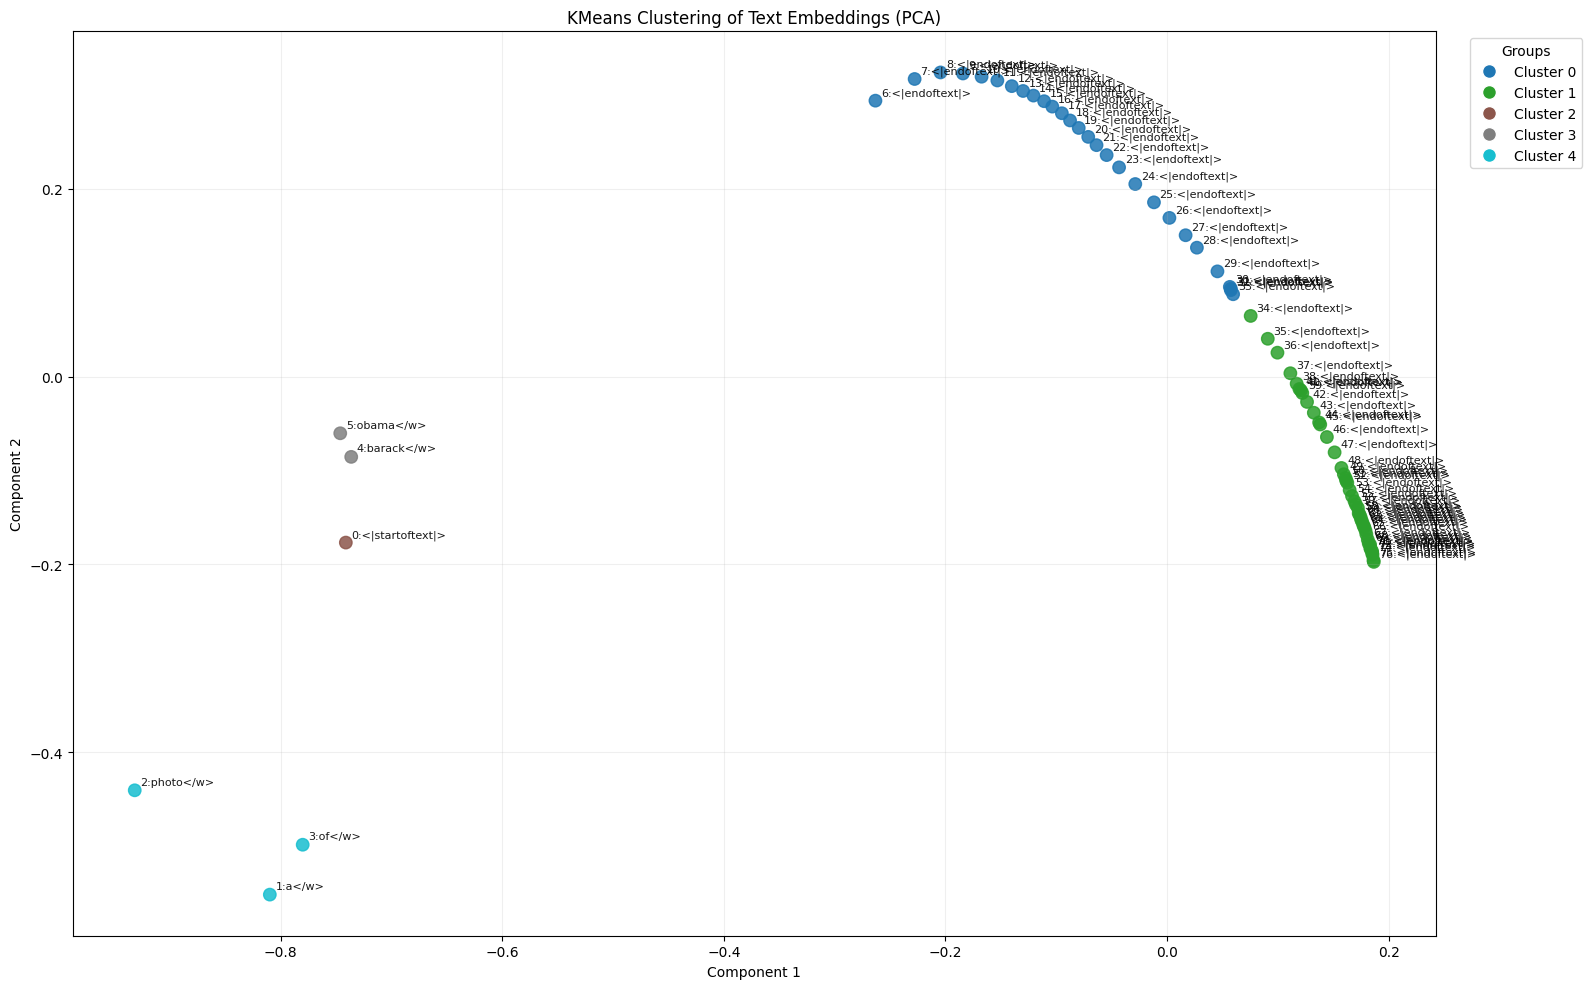

In [8]:
prompt = ['a photo of Barack Obama']

features,tokens = build_features(prompt, feature_option="text", is_normalize=True)

token_labels = [f"{idx}:{token}" for idx, token in enumerate(tokens)]

cluster_labels, kmeans_model, projected_points = kmean_clustering(
    features,
    k=5,
    is_normalize=False,
    show_plot=True,
    projection_plot="pca",
    labels=token_labels,
)


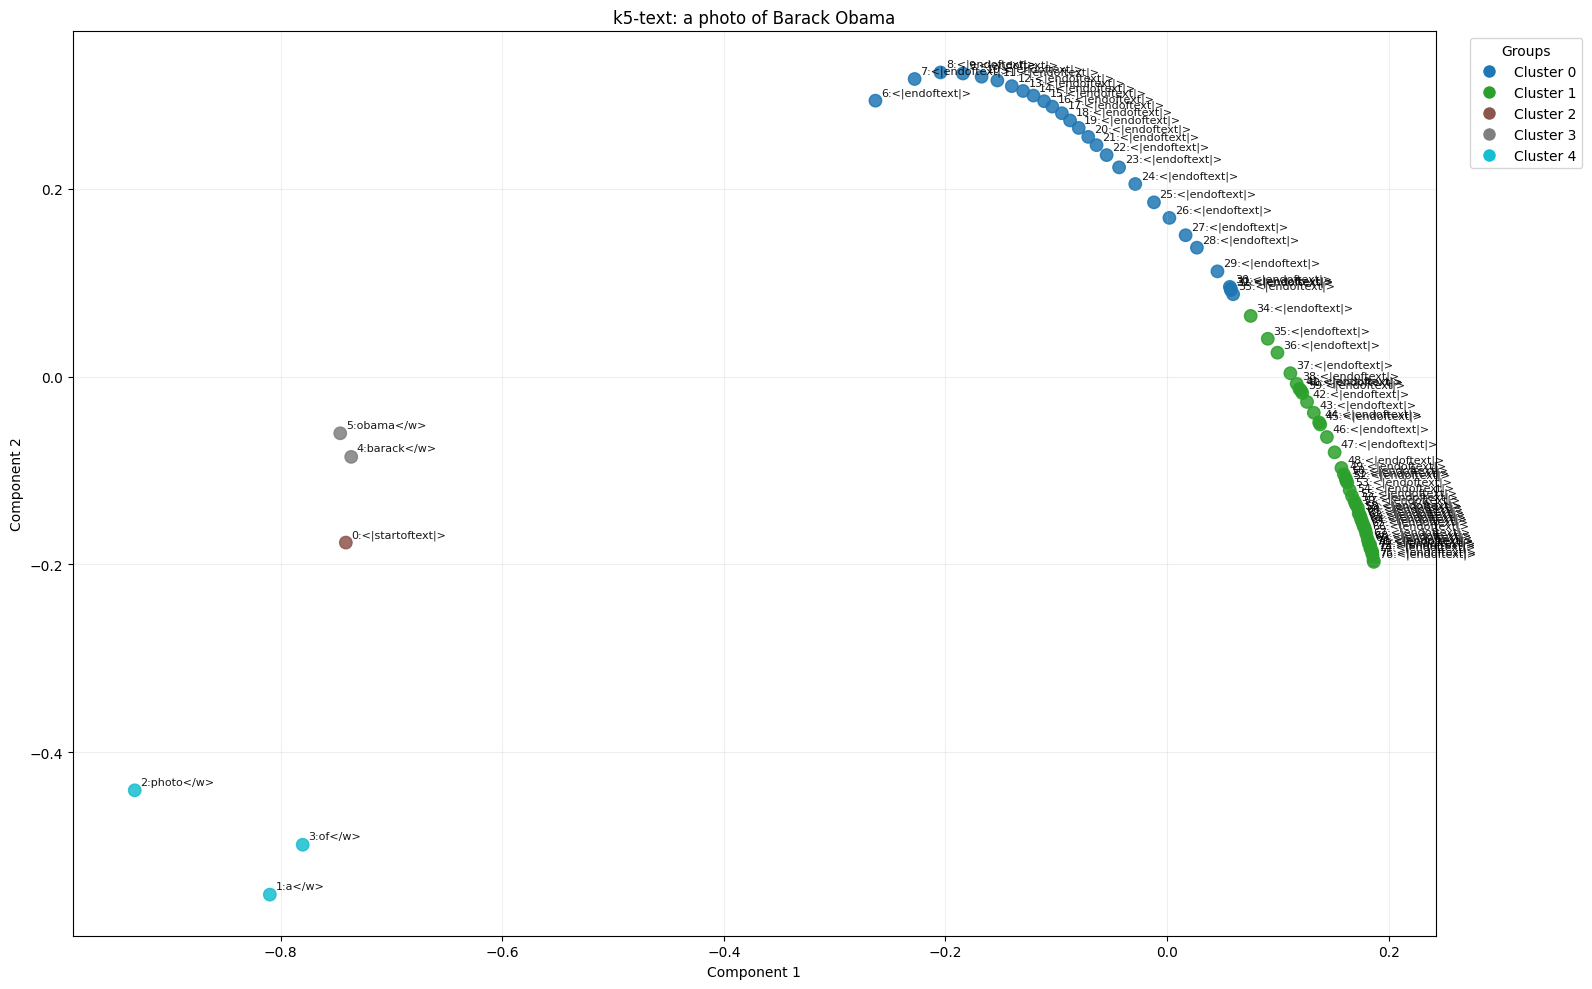

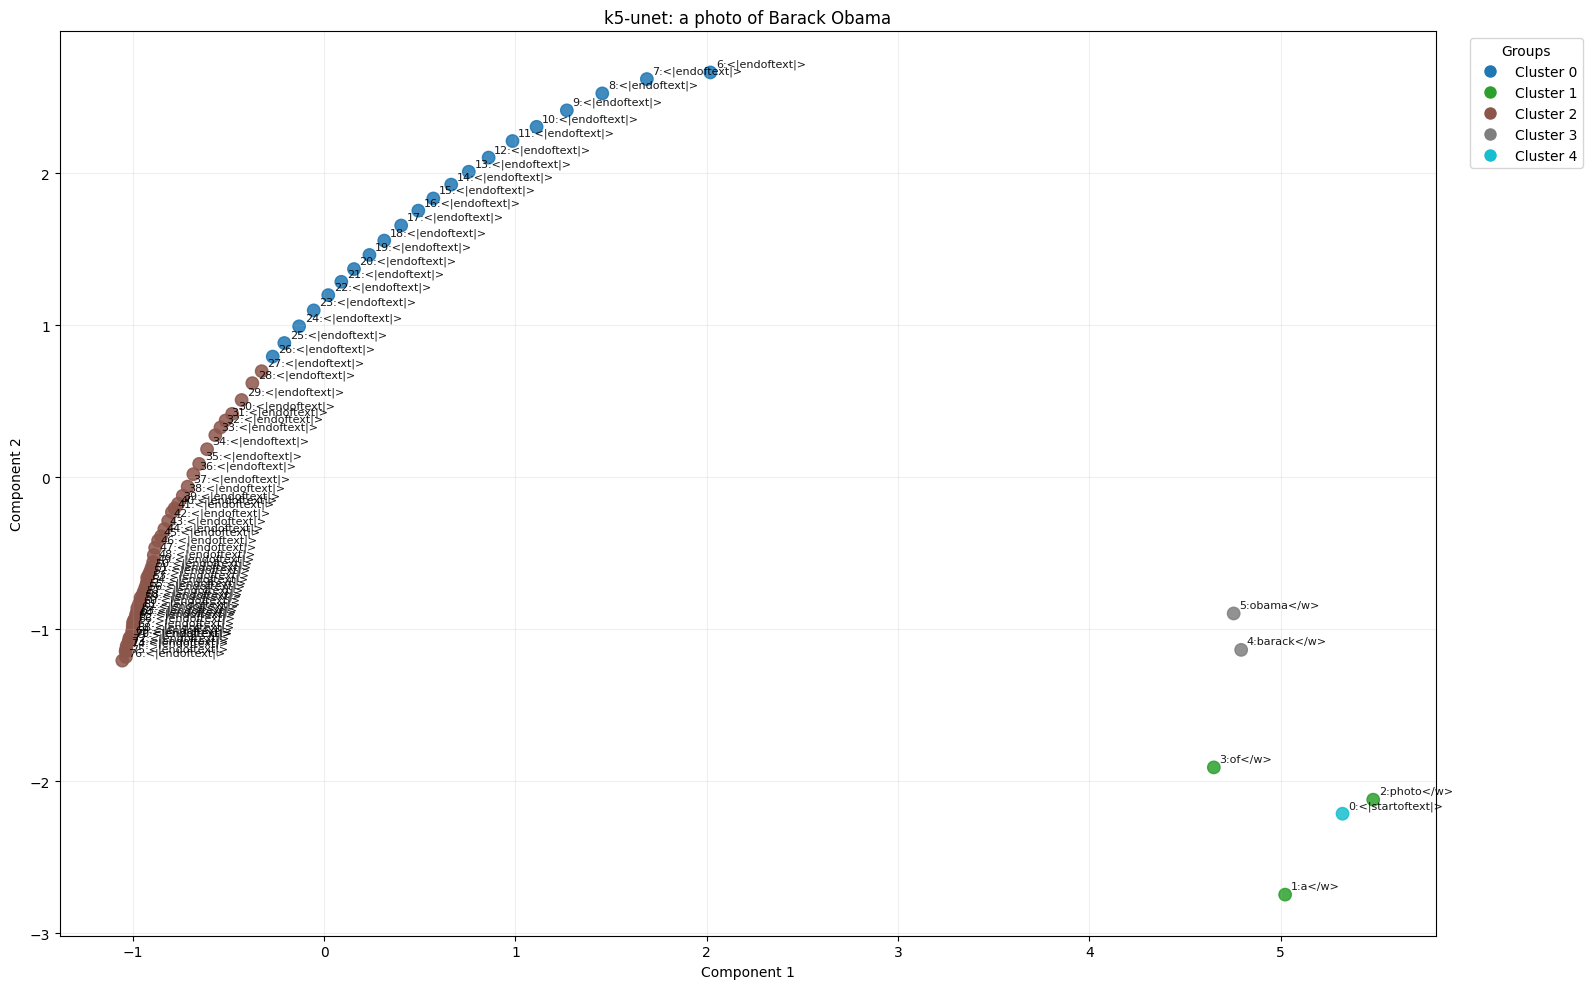

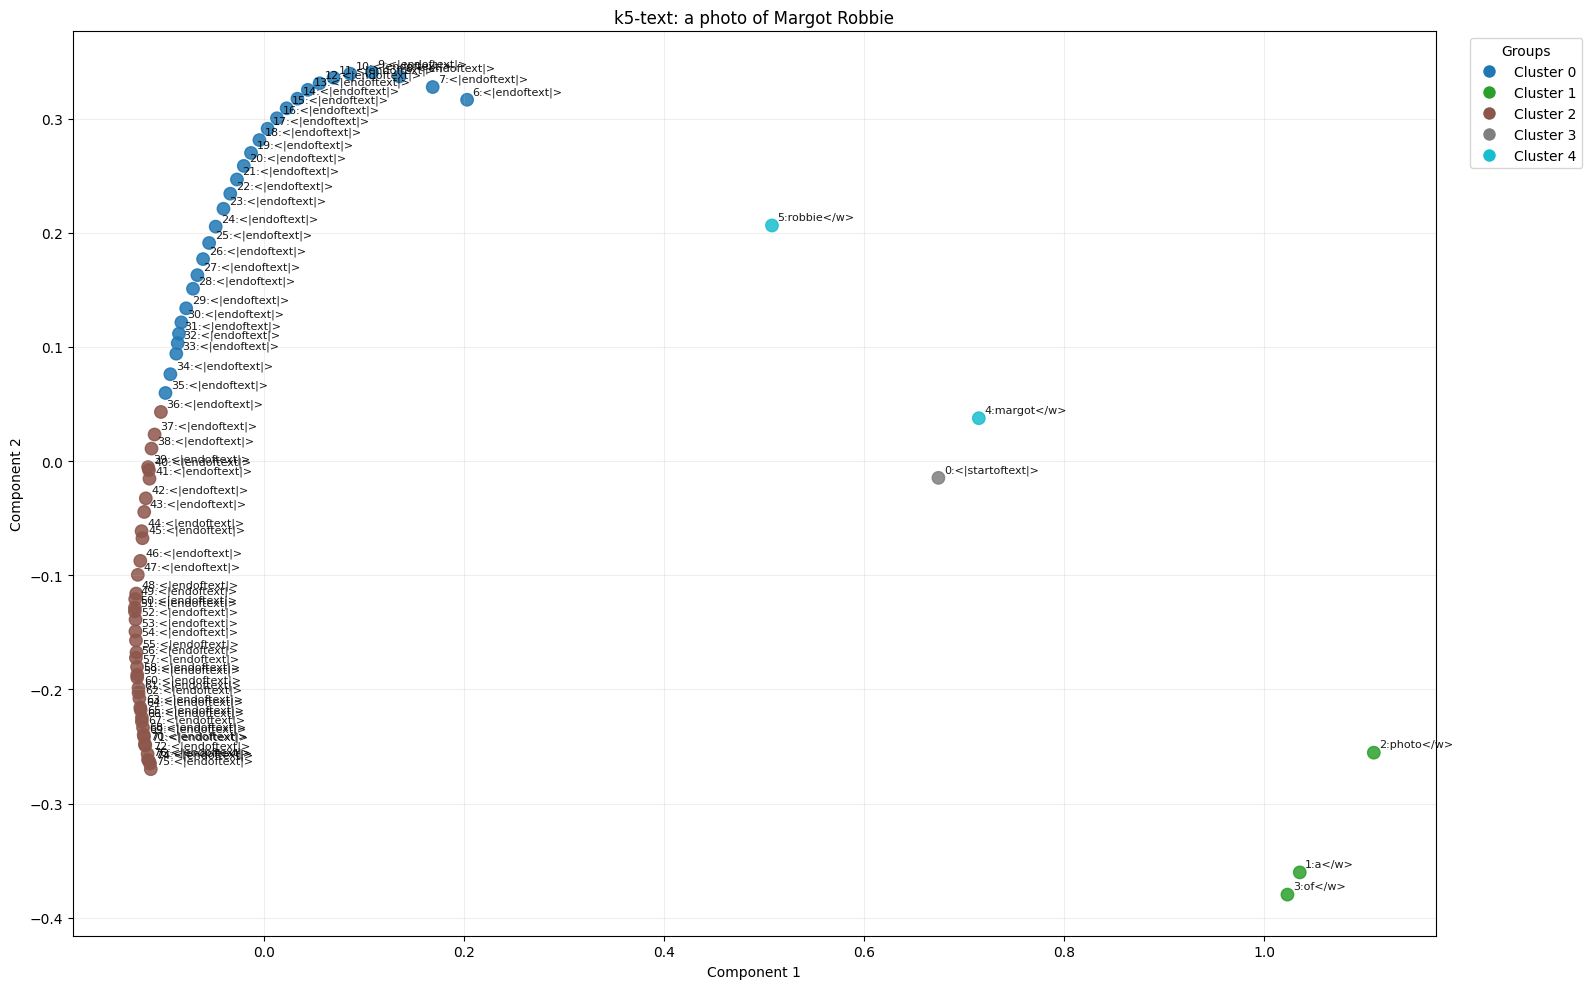

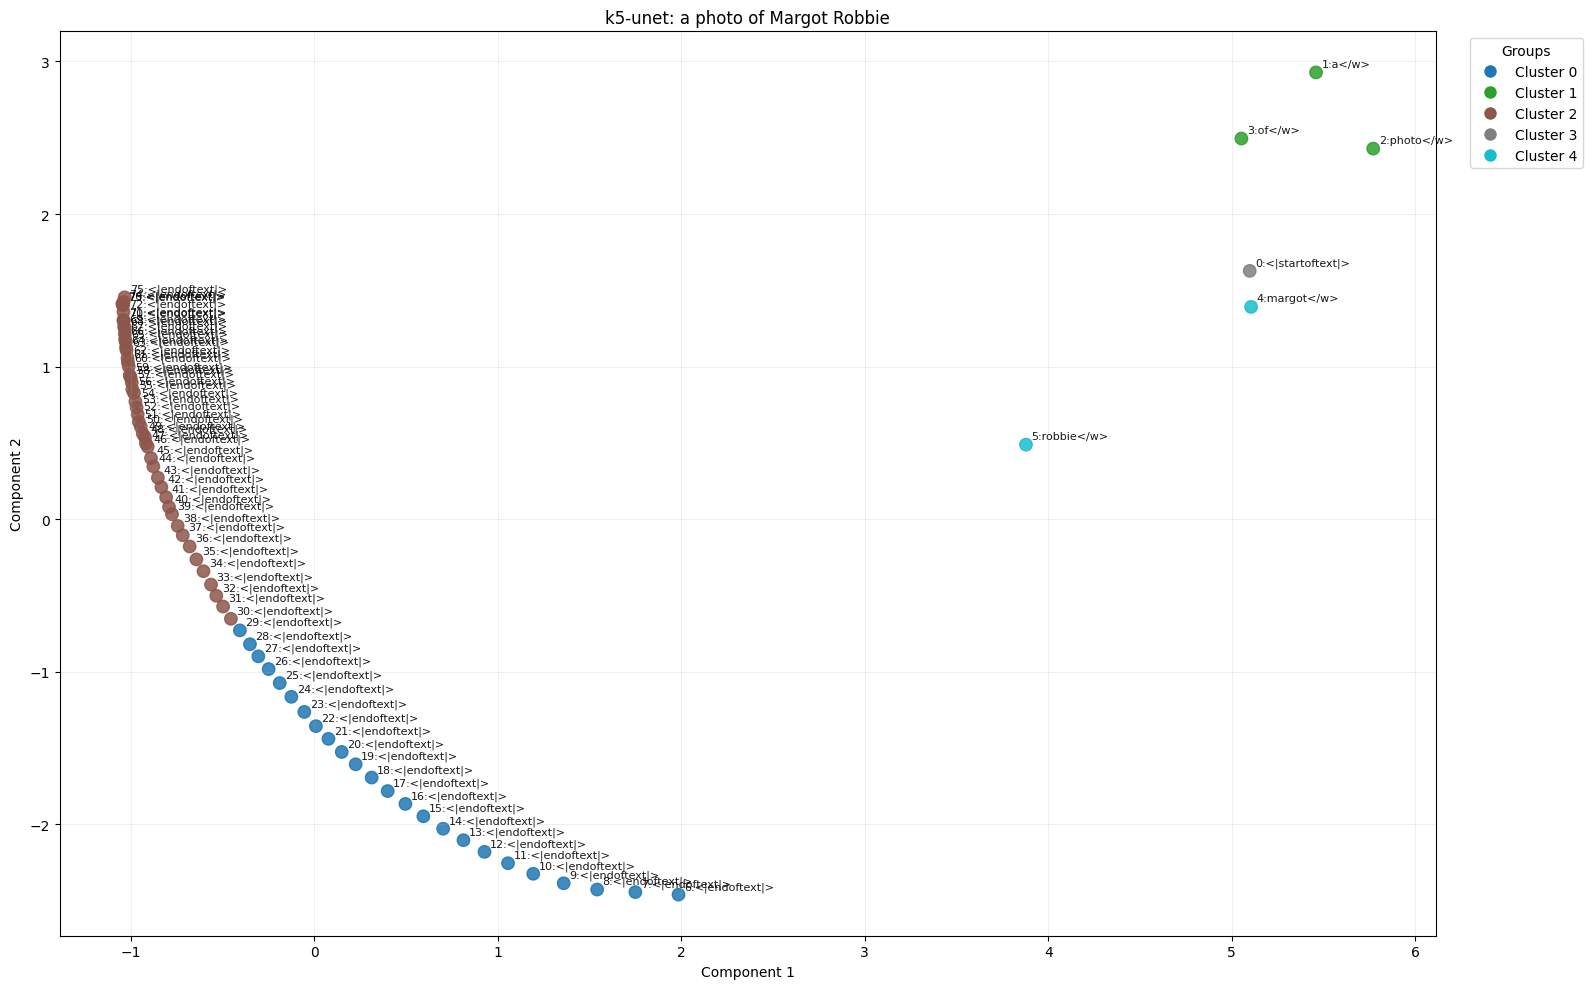

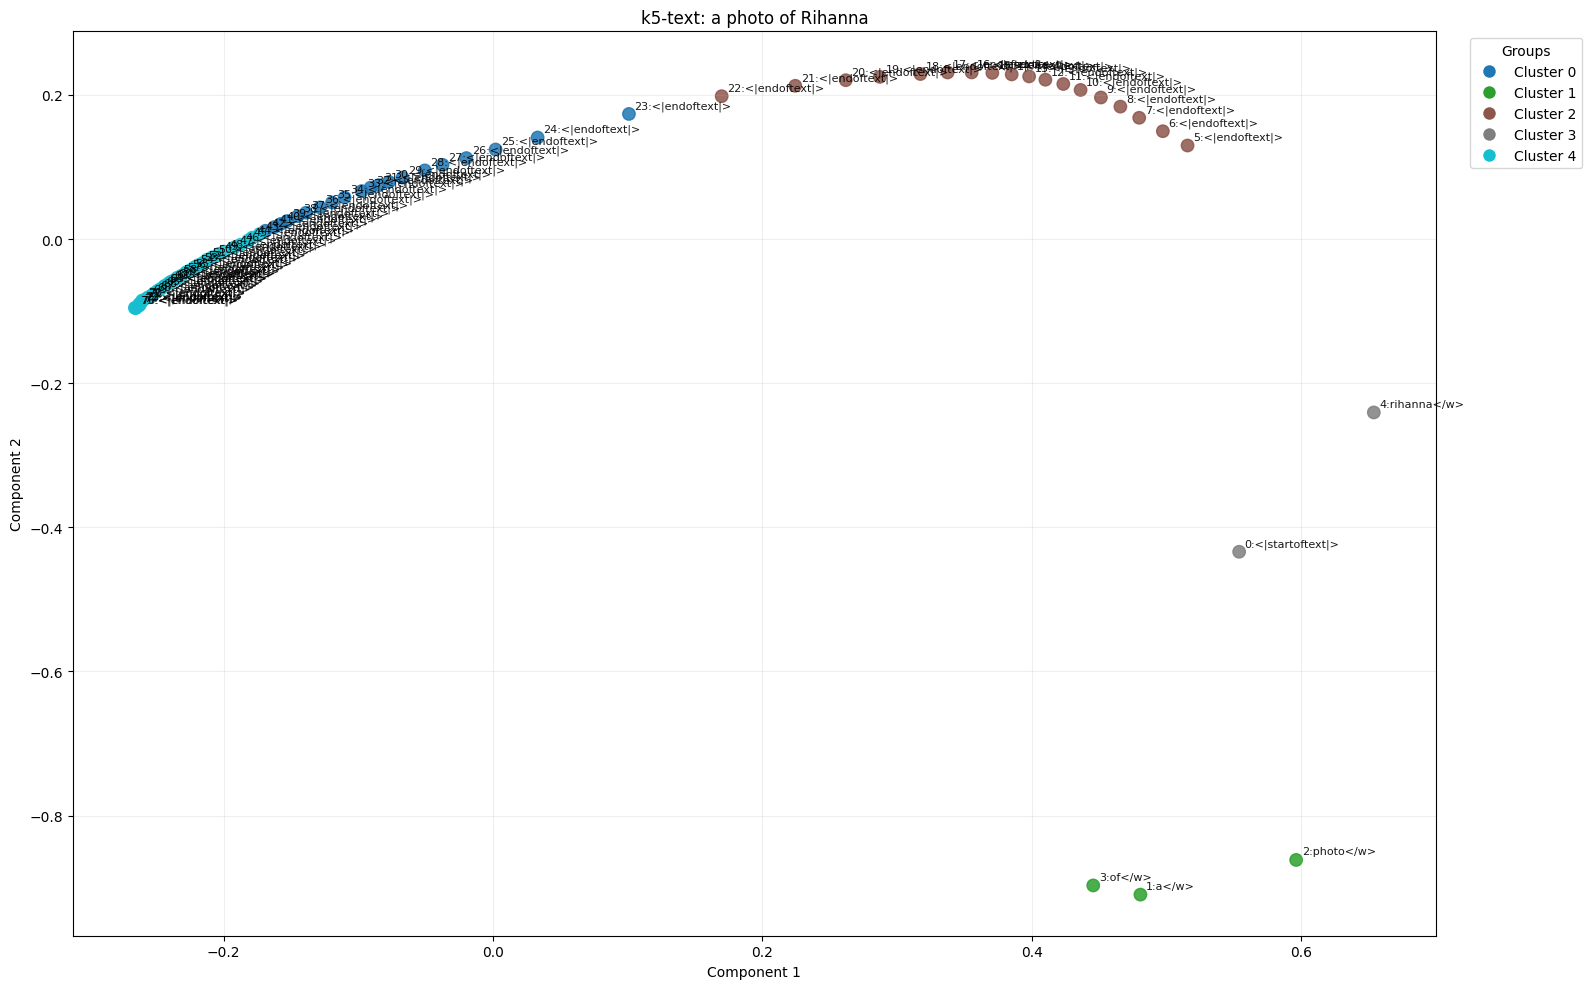

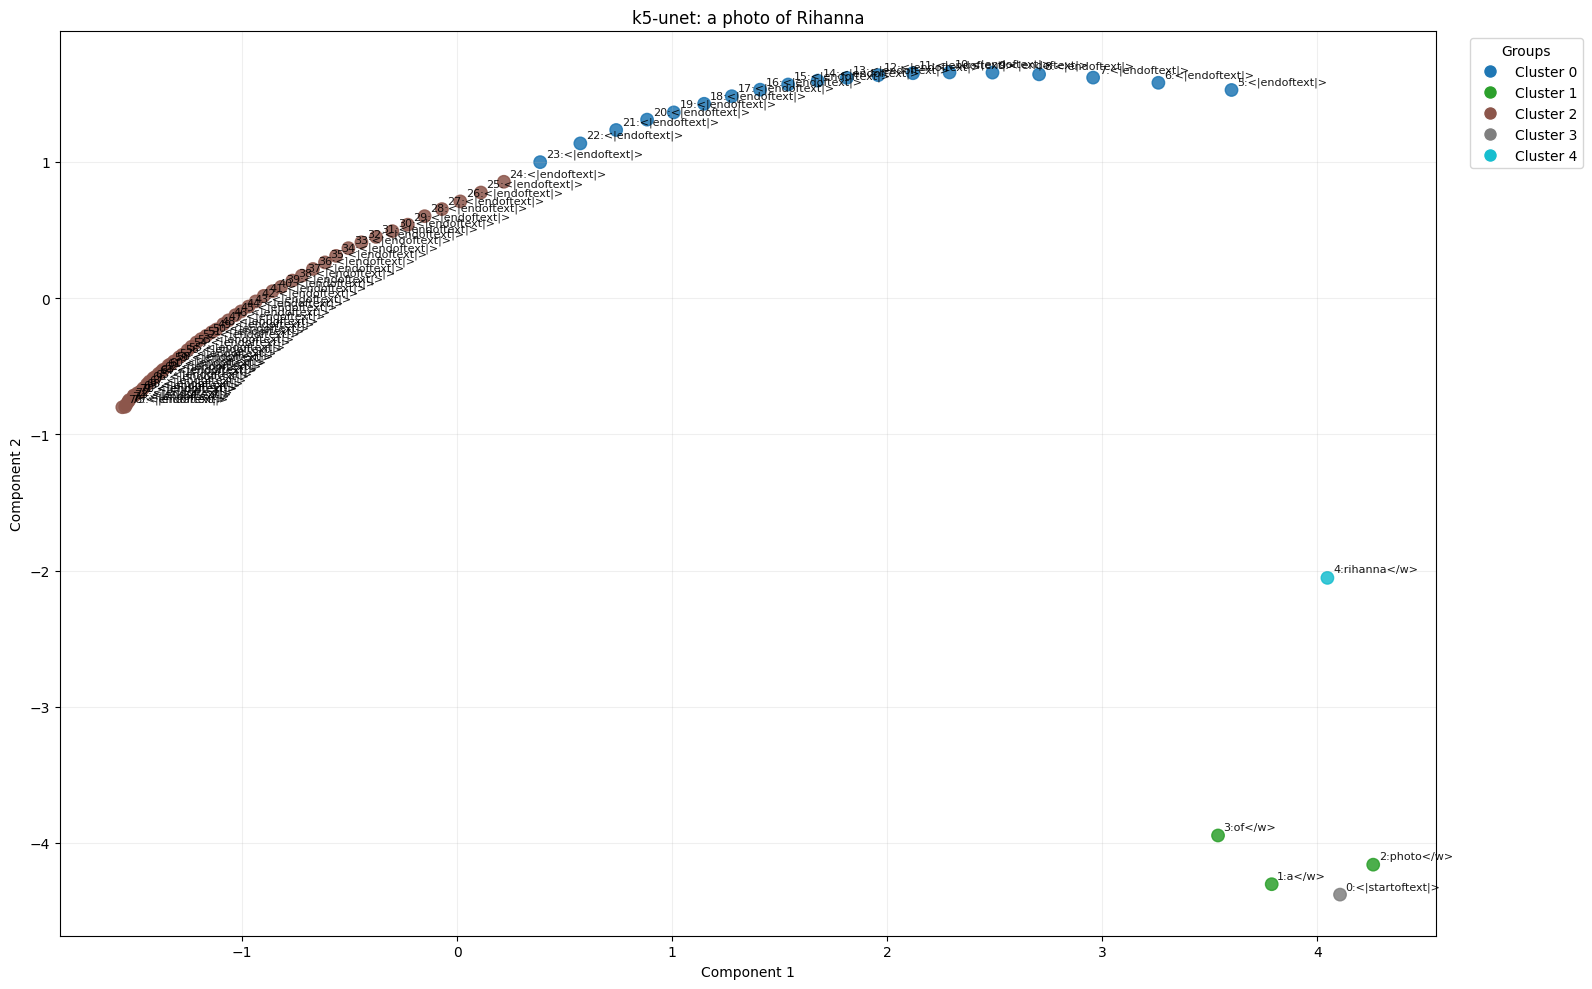

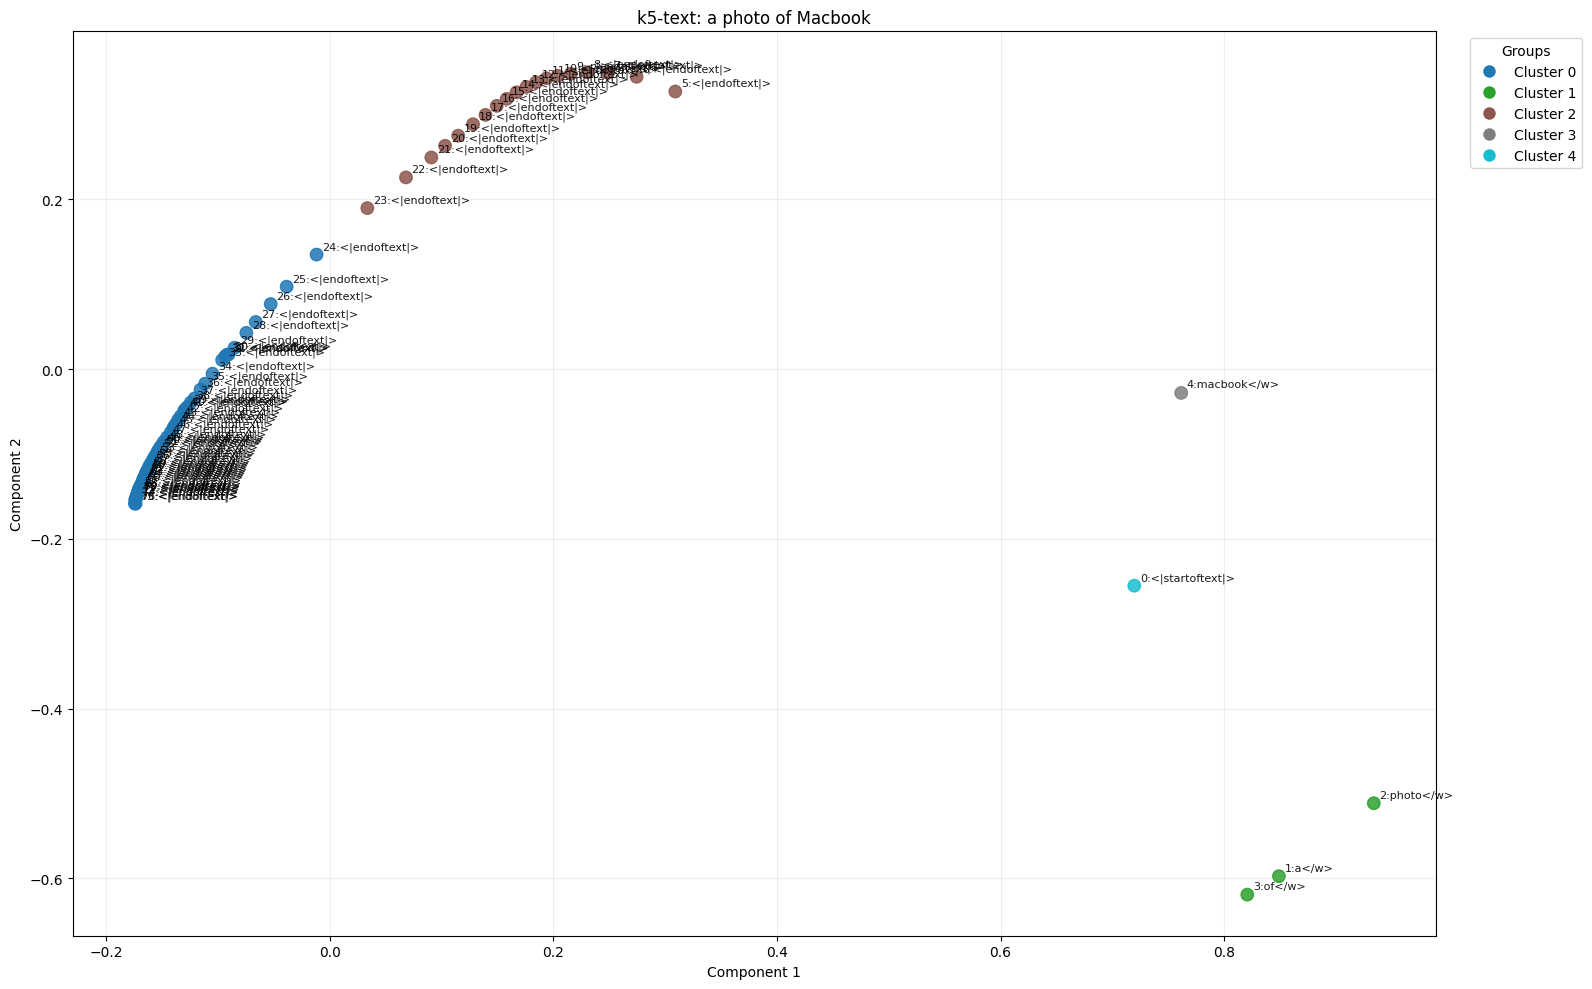

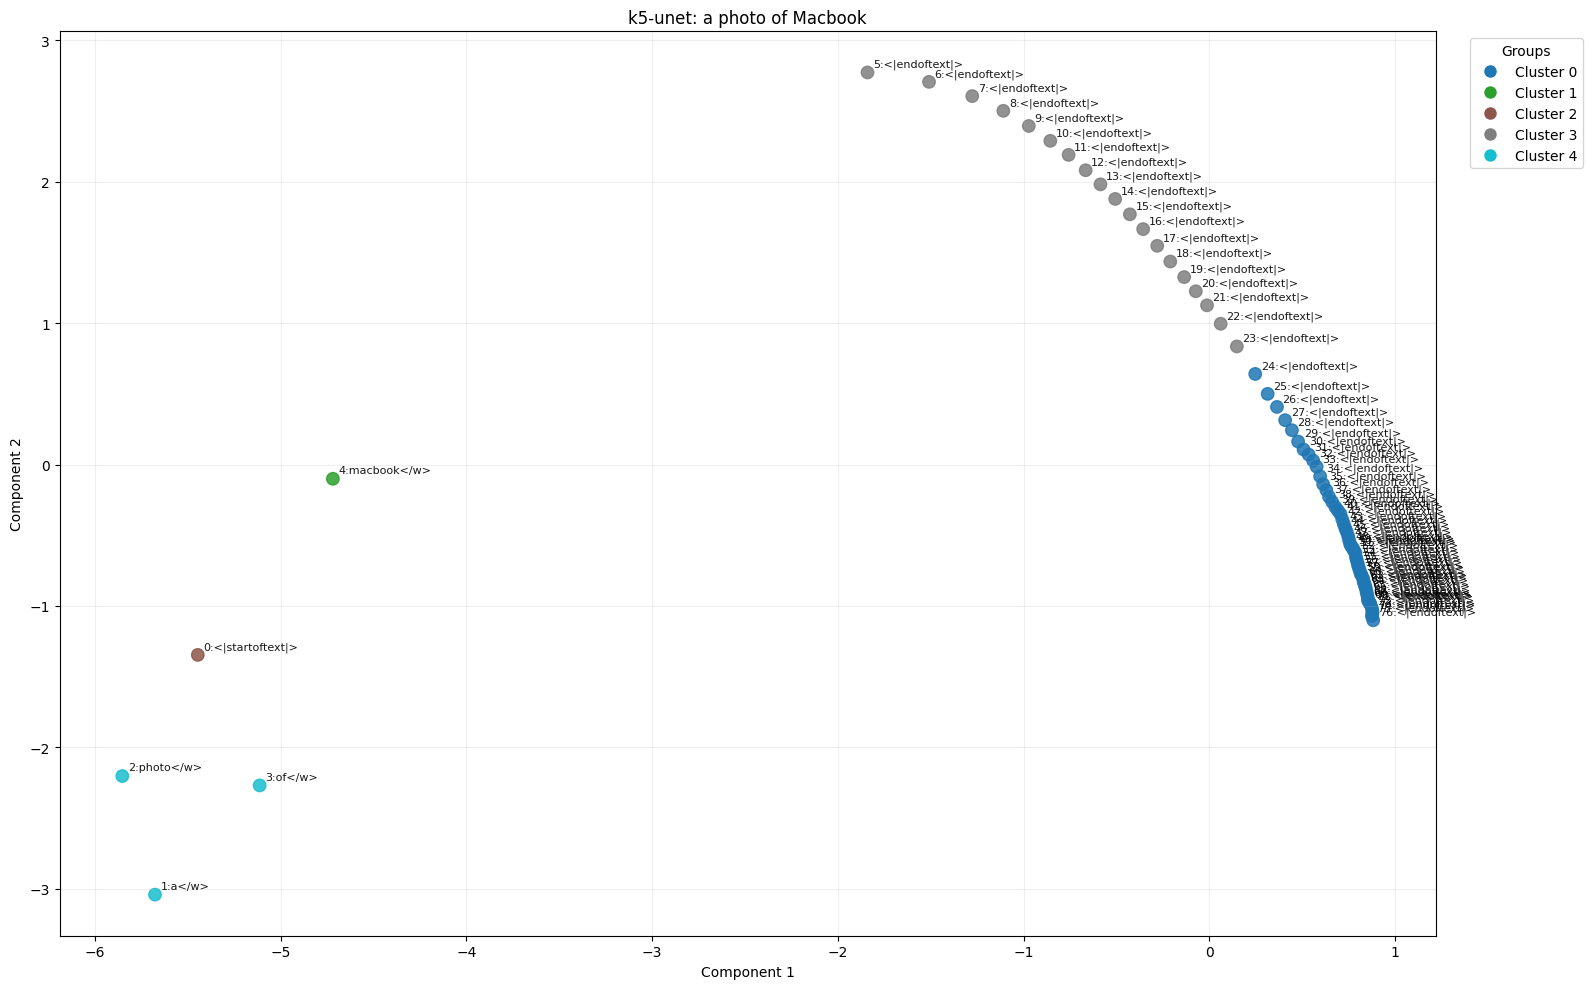

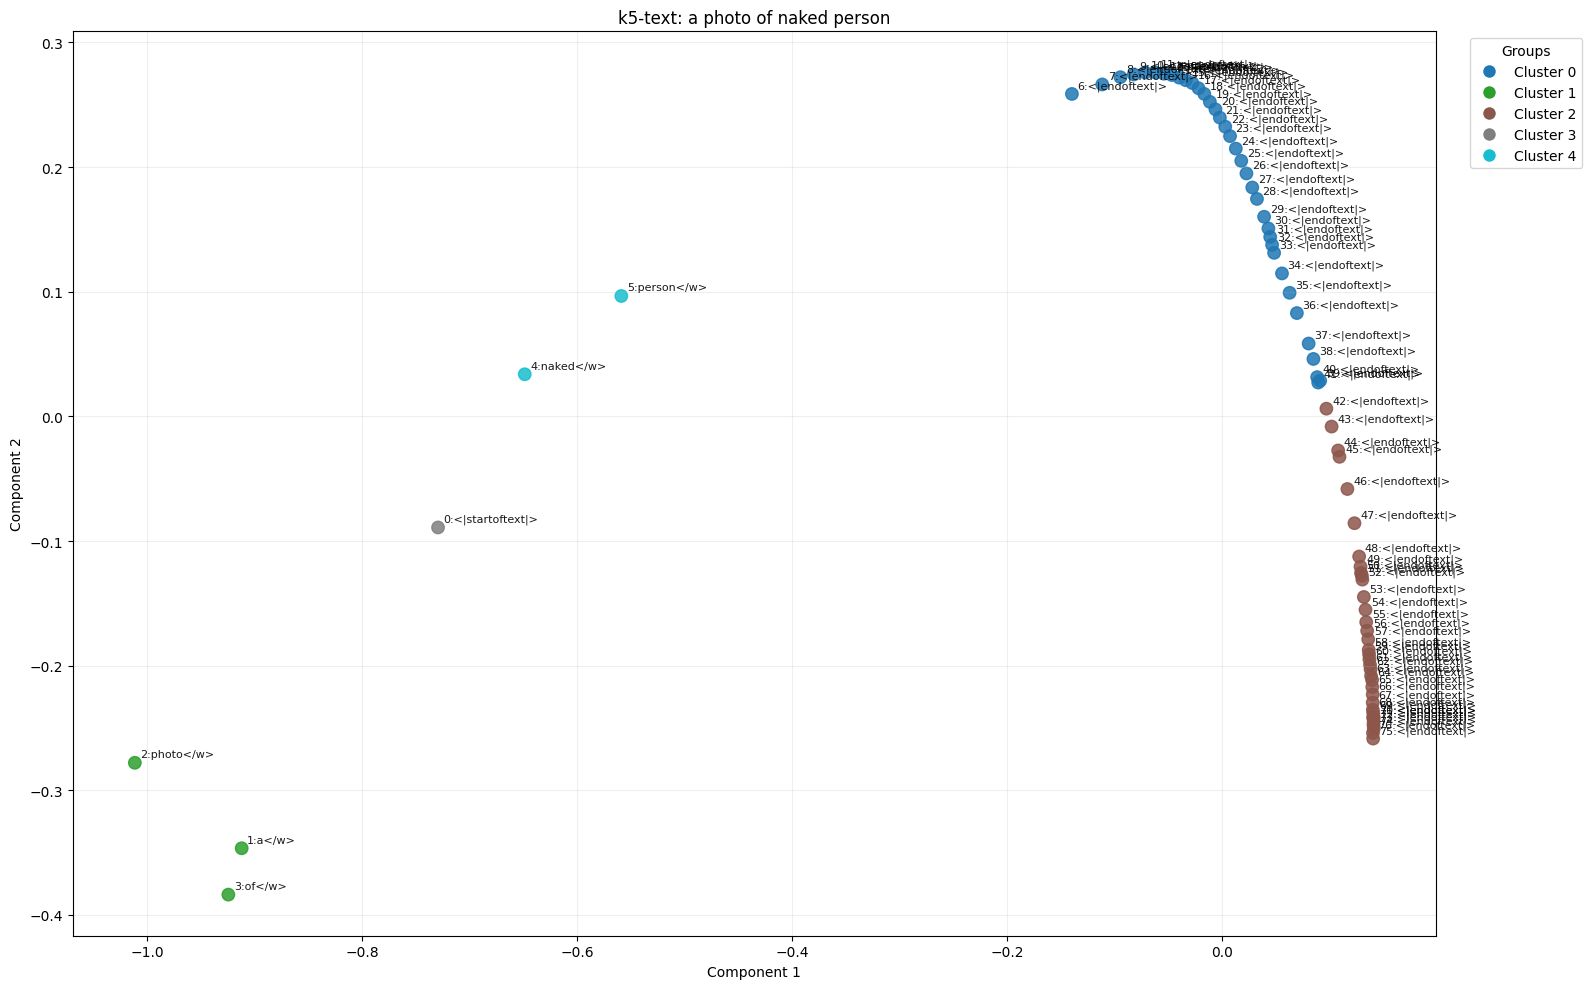

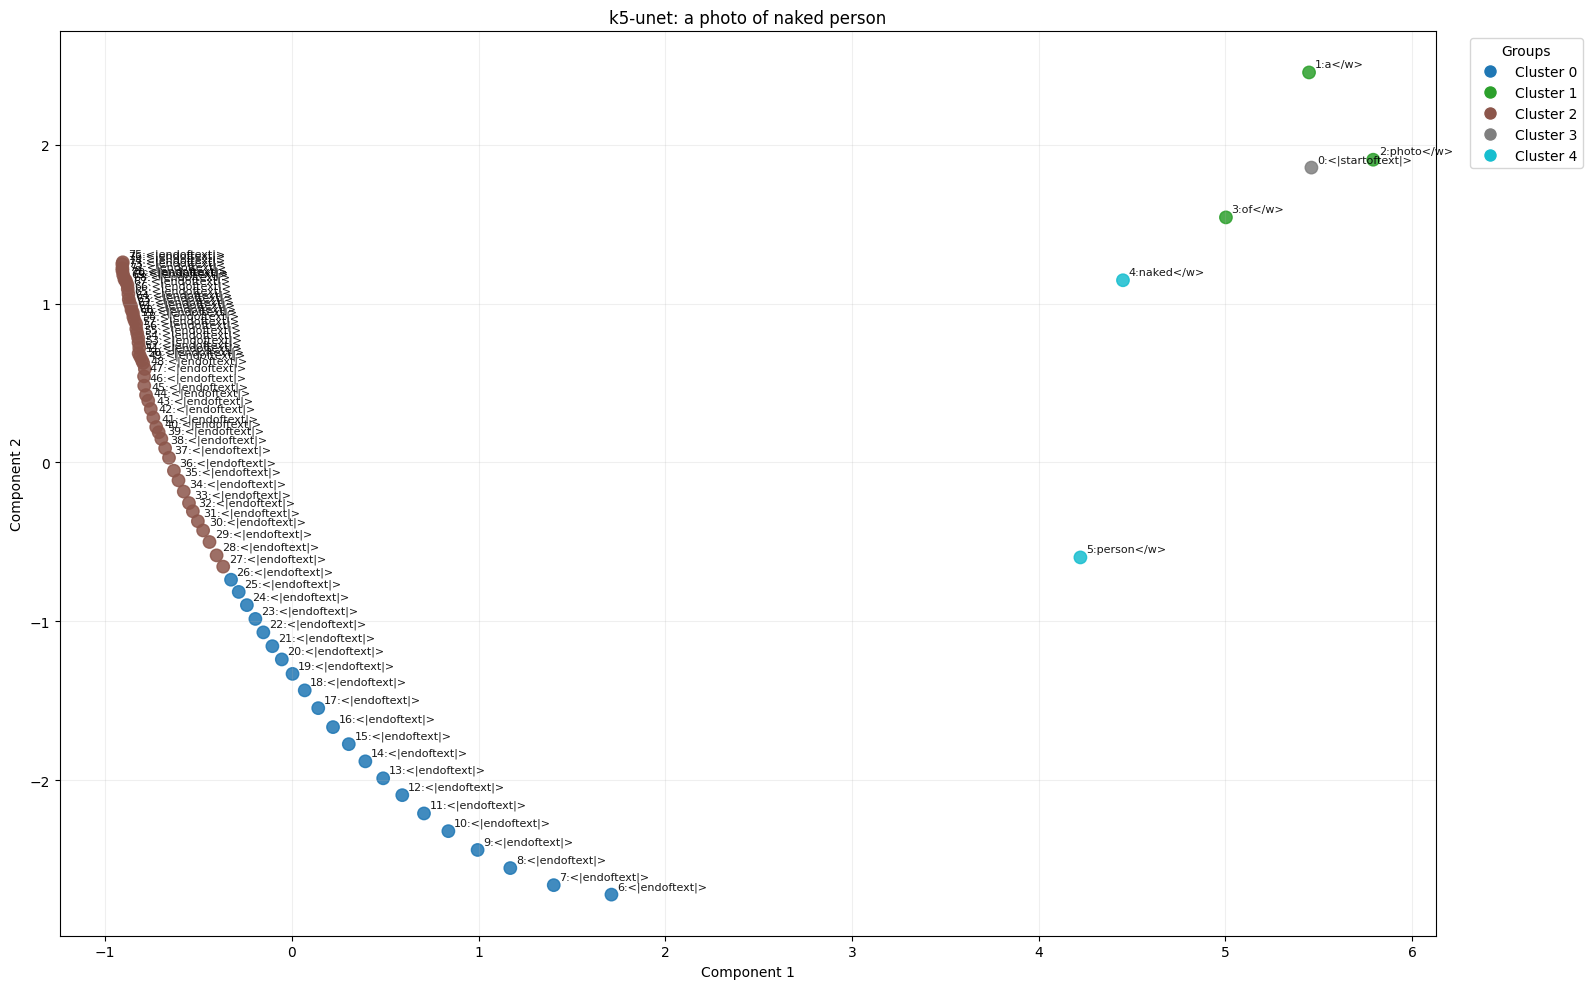

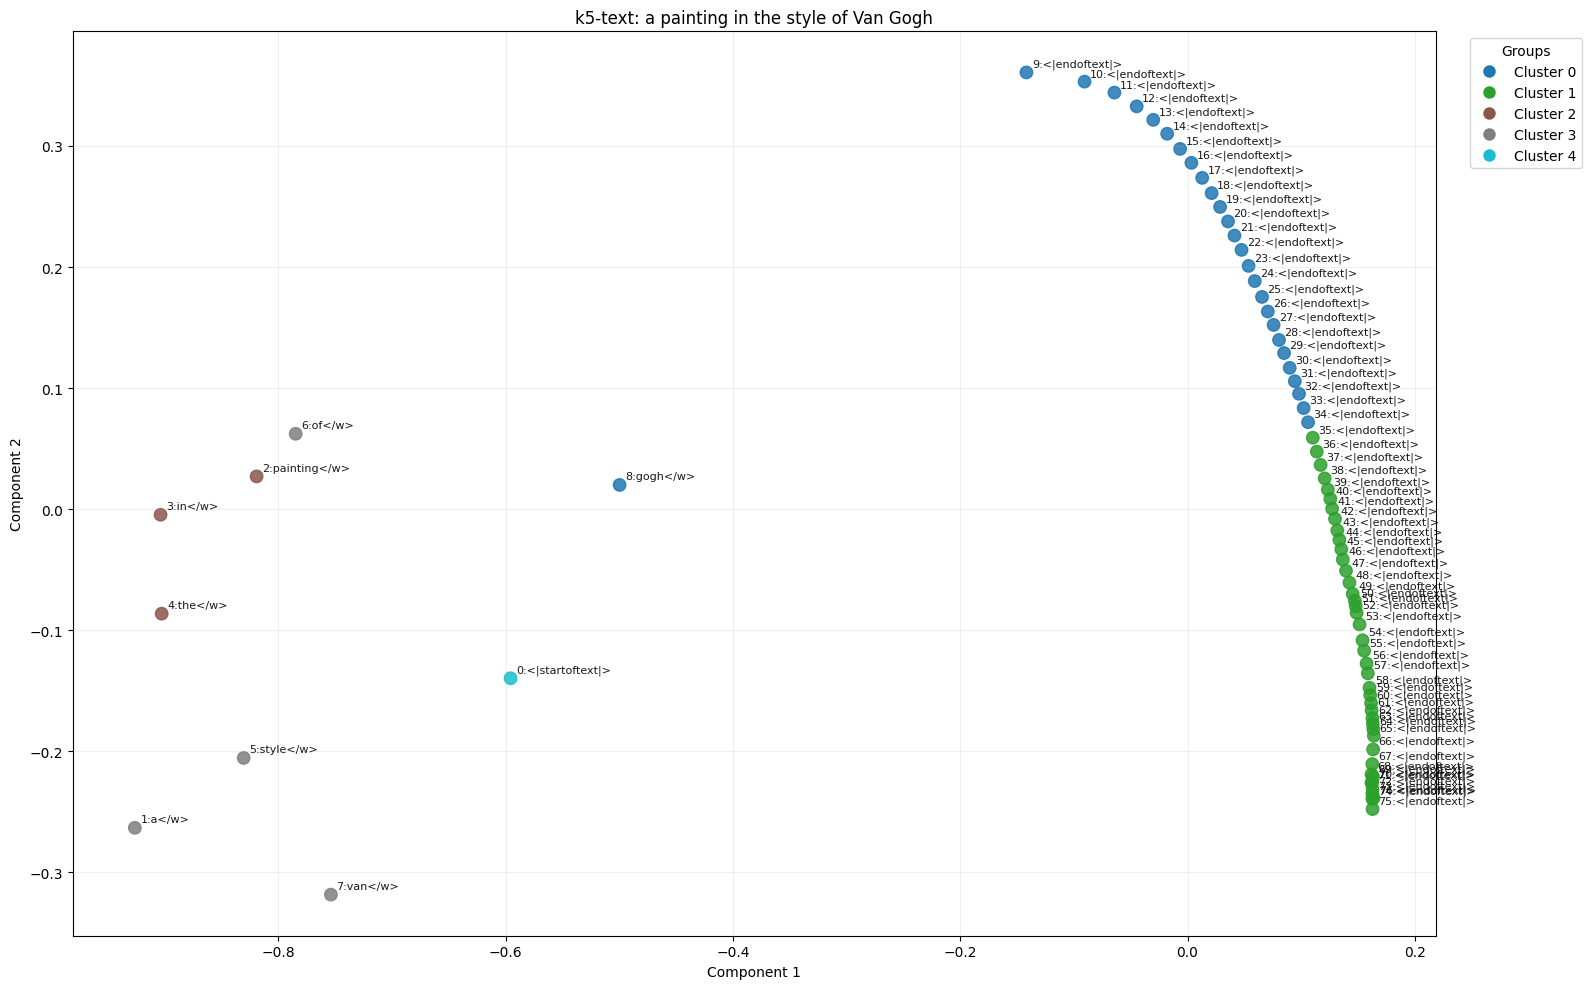

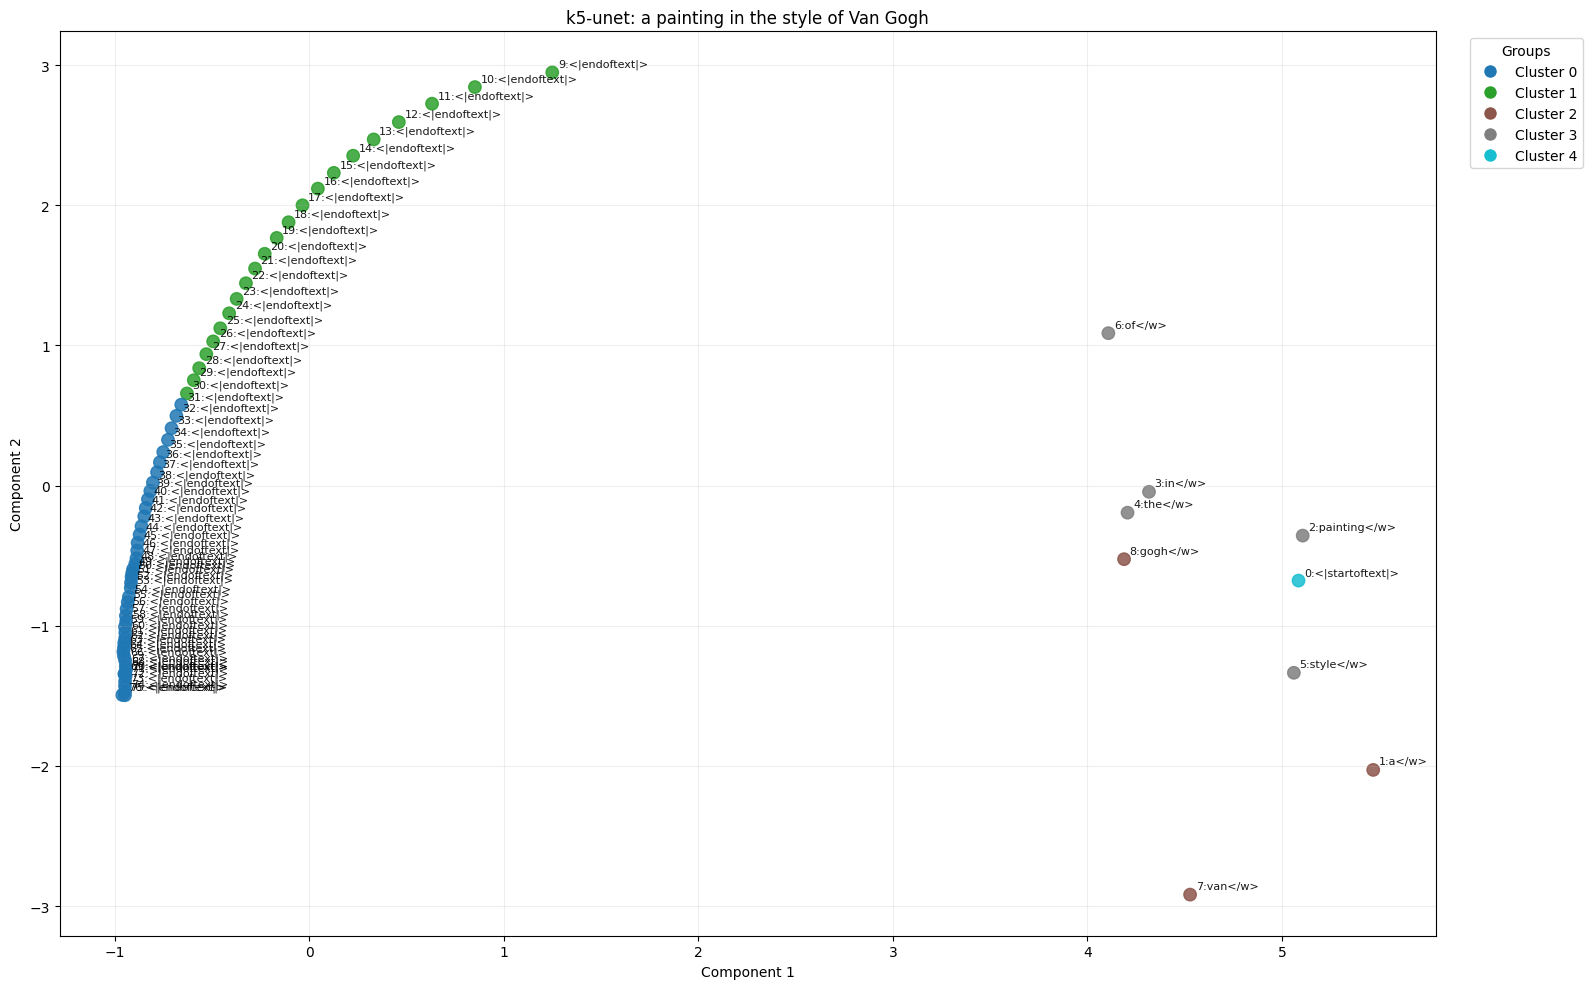

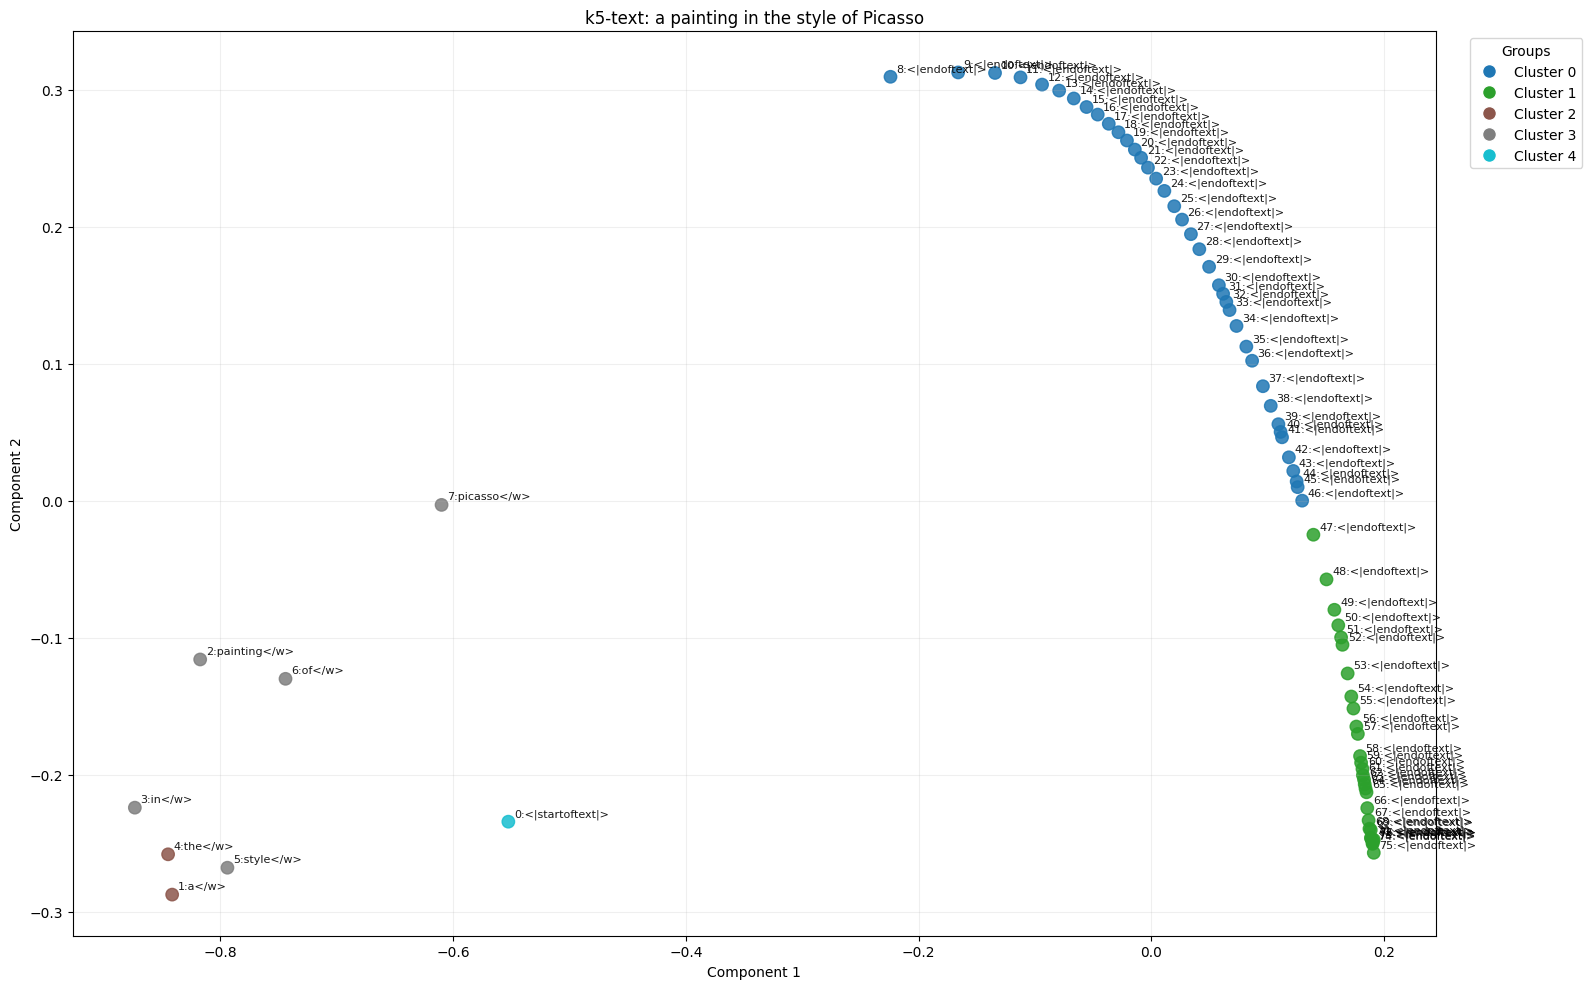

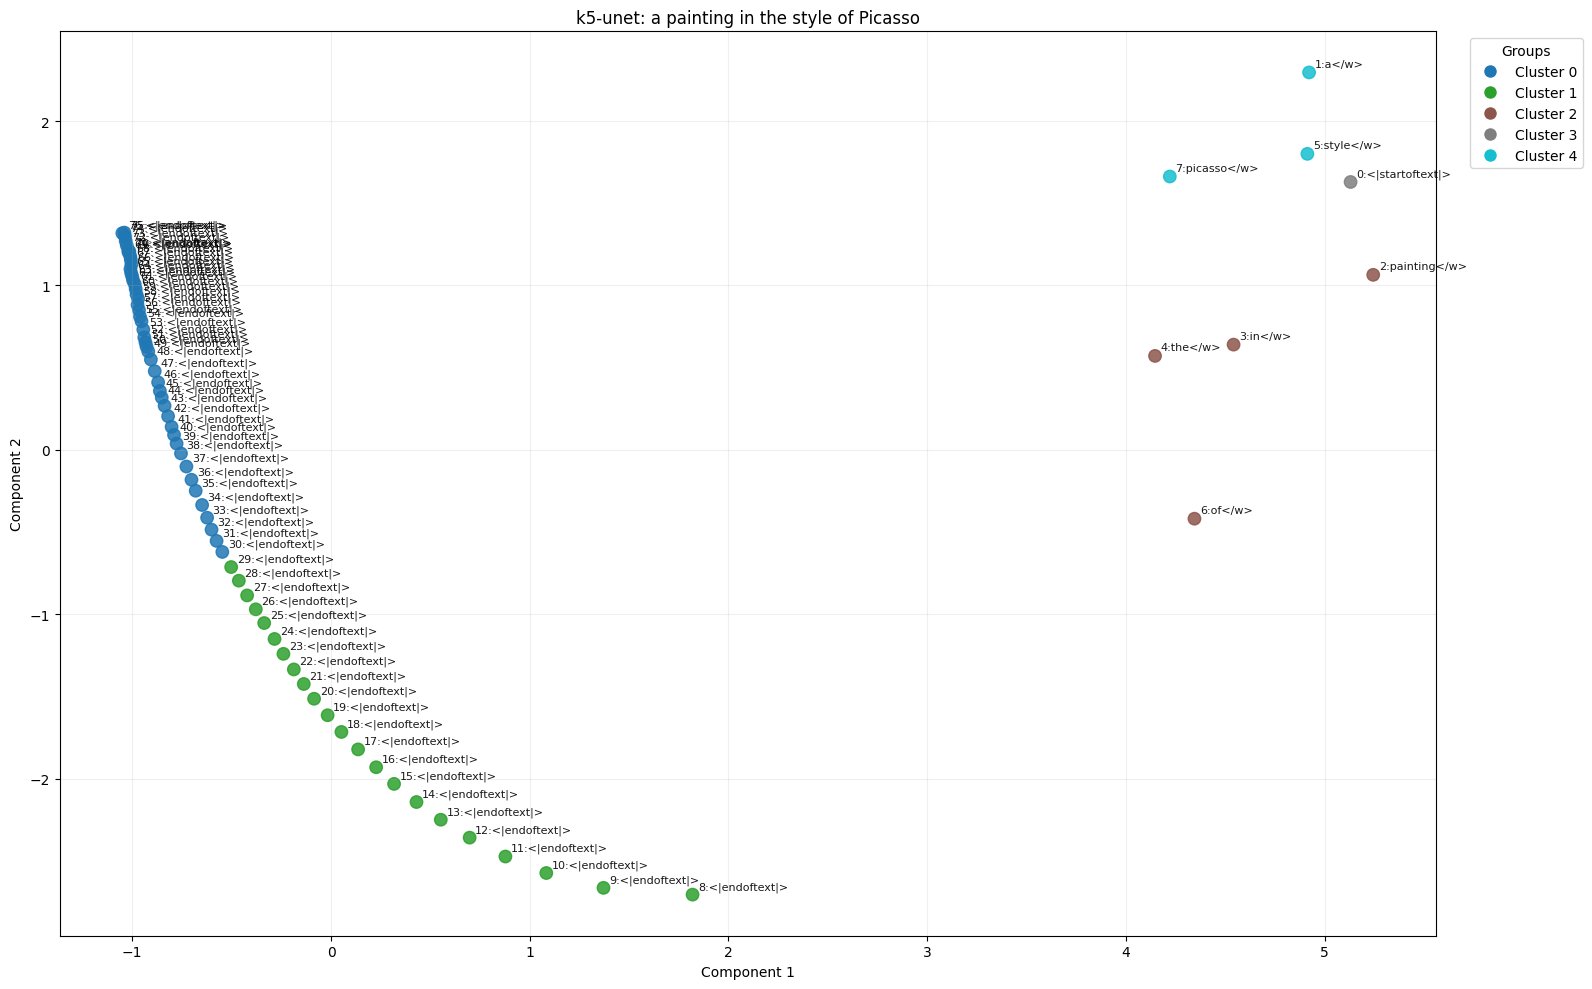

In [12]:
# prompts = ['a photo of Barack Obama']
# prompts = ['a photo of Macbook']
# prompts = ['a photo of naked person']
# prompts = ['a photo of Margot Robbie']
# prompts = ['a painting in the style of Van Gogh']
# prompts = ['a painting in the style of Picasso']

k = 5

prompts = ['a photo of Barack Obama','a photo of Margot Robbie','a photo of Rihanna',
           'a photo of Macbook','a photo of naked person','a painting in the style of Van Gogh','a painting in the style of Picasso']

feature_options = ["text", "unet"]

for prompt in prompts:
    for feature_option in feature_options:
        features,tokens = build_features([prompt], feature_option=feature_option, is_normalize=True)
        token_labels = [f"{idx}:{token}" for idx, token in enumerate(tokens)]

        cluster_labels, kmeans_model, projected_points = kmean_clustering(
            features,
            k=k,
            is_normalize=False,
            show_plot=True,
            projection_plot="pca",
            labels=token_labels,
            plot_title=f"k{k}-{feature_option}: {prompt}"
        )




In [ ]:
prompts = ['a photo of Barack Obama', '']

In [72]:
tokens

['<|startoftext|>',
 'a</w>',
 'photo</w>',
 'of</w>',
 'cat</w>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>

In [79]:
prompts = ['a photo of Barack Obama']
# prompts = ['a photo of David Beckham']
# prompts = ['a photo of Margot Robbie']
# prompts = ['a photo of Rihanna']
# prompts = ['a photo of Margot Robbie']
# prompts = ['a photo of Macbook']
# prompts = ['a photo of naked person']

# prompts = ['a painting in the style of Picasso']
# prompts = ['a painting in the style of Van Gogh']
# prompts = ['a painting in the style of Claude Monet']
# prompts = ['a photo of Grumpy cat']
# prompts = ['a photo of R2D2']


token_ids = pipe.tokenizer(prompts, padding='max_length', truncation=True, max_length=pipe.tokenizer.model_max_length, return_tensors="pt").input_ids[0]
tokens = pipe.tokenizer.convert_ids_to_tokens(token_ids)

text_embeddings = pipe.encode_prompt(prompts, device=device, num_images_per_prompt=1, do_classifier_free_guidance=False)[0][0]


token_ids
tokens
text_embeddings
text_embeddings.shape



tensor([49406,   320,  1125,   539, 22481,  4276, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
        49407, 49407, 49407, 49407, 49407, 49407, 49407])

['<|startoftext|>',
 'a</w>',
 'photo</w>',
 'of</w>',
 'barack</w>',
 'obama</w>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>',
 '<|endoftext|>'

tensor([[-0.3884,  0.0229, -0.0523,  ..., -0.4902, -0.3066,  0.0674],
        [ 0.0280, -1.3232,  0.3076,  ..., -0.5249,  0.9771,  0.6641],
        [ 1.1543,  0.1326,  0.7891,  ..., -2.1055, -1.1523, -0.3296],
        ...,
        [-0.9097,  0.2350, -0.8228,  ...,  0.3469, -0.3086, -0.2217],
        [-0.9053,  0.2384, -0.8188,  ...,  0.3411, -0.3022, -0.2096],
        [-0.8789,  0.2678, -0.7451,  ...,  0.3491, -0.2686, -0.2476]],
       device='cuda:0', dtype=torch.float16, grad_fn=<SelectBackward0>)

torch.Size([77, 768])

## Clustering

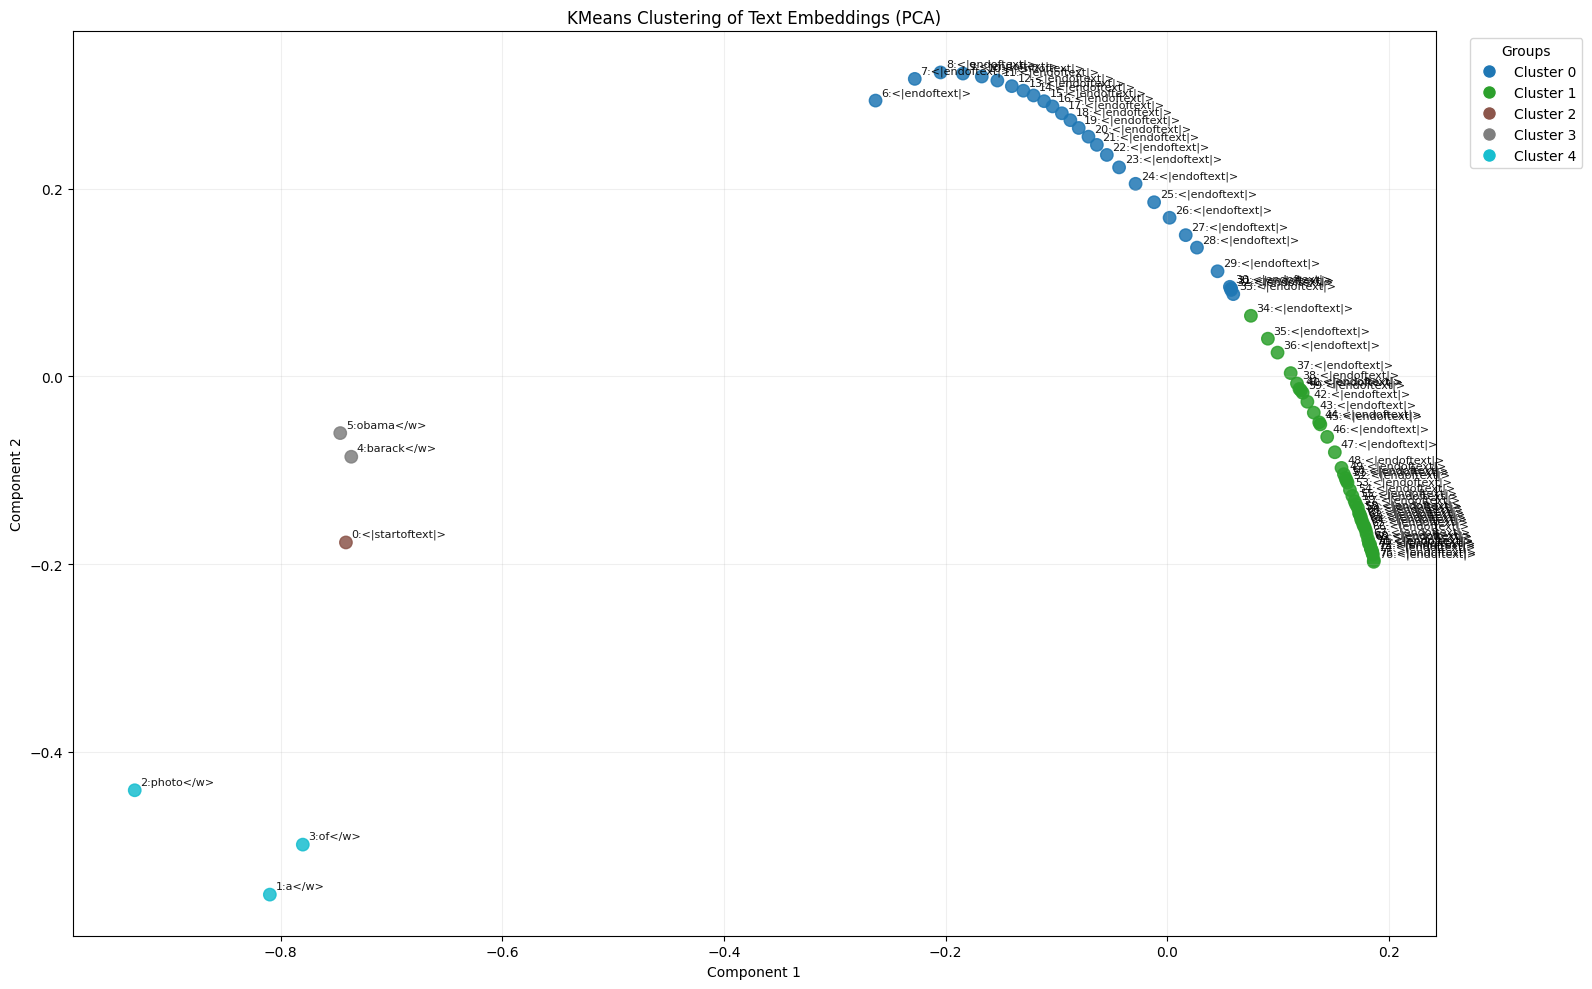

array([2, 4, 4, 4, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [ ]:
token_labels = [f"{idx}:{token}" for idx, token in enumerate(tokens)]

cluster_labels, kmeans_model, projected_points = kmean_clustering(
    text_embeddings,
    k=5,
    is_normalize=True,
    show_plot=True,
    projection_plot="pca",
    labels=token_labels,
)

cluster_labels

In [ ]:
token_labels = [f"{idx}:{token}" for idx, token in enumerate(tokens)]

cluster_labels, kmeans_model, projected_points = kmean_clustering(
    text_embeddings,
    k=10,
    normalize=True,
    show_plot=True,
    projection_plot="pca",
    labels=token_labels,
)

cluster_labels

In [14]:
pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [umap-learn]4 [numba]
Note: you may need to restart the kernel to use updated packages.
